In [ ]:
Analisi probabilistica e Bayes con Python su Data Warehouse TechStore
Ripasso Teorico
* Probabilità
* Probabilità condizionata
* Tabelle di contingenza
* Teorema di Bayes

In [3]:
import psycopg, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

conn = psycopg.connect(host='its_postgresql', port=5432, dbname='techstore_dw', user='postgres', password='postgres')
print('Connessione OK')

Connessione OK


In [ ]:
Esercizio 1 - Distribuzione delle categorie prodotto

In [8]:
df = pd.read_sql('''SELECT categoria, COUNT(*) n FROM fact_vendite fv JOIN dim_prodotto dp ON fv.prodotto_sk=dp.prodotto_sk GROUP BY categoria''', conn)
df['prob'] = df['n'] / df['n'].sum()
df

/tmp/ipykernel_350/959486918.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('''SELECT categoria, COUNT(*) n FROM fact_vendite fv JOIN dim_prodotto dp ON fv.prodotto_sk=dp.prodotto_sk GROUP BY categoria''', conn)


,categoria,n,prob
0,Accessori,28262,0.143572
1,Audio,22707,0.115352
2,Componenti,22345,0.113513
3,Gaming,22474,0.114169
4,Laptop,28087,0.142683
5,Smartphone,28092,0.142708
6,Smartwatch,22442,0.114006
7,Tablet,22440,0.113996


In [ ]:
Esercizio 2 - Distribuzione della fascia di età

In [17]:
df_eta = pd.read_sql('''SELECT dc.fascia_eta, COUNT(*) AS n_eta
FROM fact_vendite fv 
JOIN dim_cliente dc ON dc.cliente_sk = fv.cliente_sk 
GROUP BY dc.fascia_eta''', conn)
df_eta['prob_eta'] = df_eta['n_eta'] / df_eta['n_eta'].sum()
df_eta

/tmp/ipykernel_350/3440830027.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_eta = pd.read_sql('''SELECT dc.fascia_eta, COUNT(*) AS n_eta


,fascia_eta,n_eta,prob_eta
0,18-24,18684,0.094915
1,25-39,44743,0.227296
2,40-59,59692,0.303238
3,60+,73730,0.374551


In [ ]:
Esercizio 3 - Tabella di contingenza Categoria x Fascia età

/tmp/ipykernel_350/1557034855.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ct = pd.read_sql('''


<Axes: xlabel='categoria', ylabel='fascia_eta'>

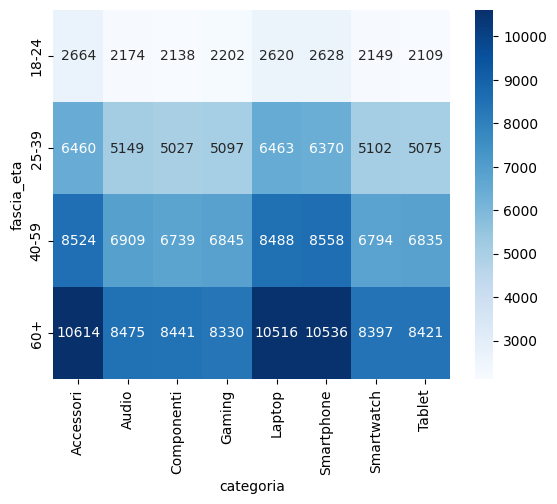

In [20]:
df_ct = pd.read_sql('''
SELECT dc.fascia_eta, dp.categoria, COUNT(*) AS n
FROM fact_vendite fv
JOIN dim_cliente dc ON fv.cliente_sk = dc.cliente_sk
JOIN dim_prodotto dp ON fv.prodotto_sk = dp.prodotto_sk
GROUP BY dc.fascia_eta, dp.categoria
''', conn)
pivot = df_ct.pivot(index='fascia_eta', columns='categoria', values='n')
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')

In [ ]:
Esercizio 4 - Probabilità condizionata: P(laptop|18-25)

In [39]:
#P(laptop|18-25)
df_ct
# (completare con P(A|B) = P(A, B) / P(B))
# Esercizio 4 - Probabilità condizionata P(Categoria|Fascia Eta)

# Seleziona la riga corrispondente alla fascia di età desiderata
# In questo esempio consideriamo la fascia 18-25

# P(Categoria=Laptop e 18-25)/P(18-25)

# conteggio per categoria e fascia d'età
df_ct = pd.read_sql('''
SELECT dc.fascia_eta, dp.categoria, COUNT(*) AS n
FROM fact_vendite fv
JOIN dim_cliente dc ON fv.cliente_sk = dc.cliente_sk
JOIN dim_prodotto dp ON fv.prodotto_sk = dp.prodotto_sk
GROUP BY dc.fascia_eta, dp.categoria
''', conn)
df_ct

# calcolo P(B) - probabilità di fascia d'età 18-24
total_eta = df_ct[df_ct['fascia_eta'] == '18-24']['n'].sum()
p_b = total_eta/df_ct['n'].sum()
print(p_b)

# P(A|B) = P(A intersection B) / P(B)
n_joint = df_ct[(df_ct['categoria'] == 'Laptop') & (df_ct['fascia_eta'] == '18-24')]['n'].iloc[0]
p_a_joint_b = n_joint/df_ct['n'].sum()
print(p_a_joint_b)

p_cond = p_a_joint_b/p_b
print(f"P(Laptop|18-24) = {p_cond:.2f}")

0.09491539200097537
0.013309694232635167
P(Laptop|18-24) = 0.14


/tmp/ipykernel_350/670595211.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ct = pd.read_sql('''


In [ ]:
Esercizio 5 - Probabilità condizionata inversa: P(18-25|Smartphone)

In [50]:
# P(18-24|Smartphone)
# usare tabella df_ct
# seleziono la colonna corrispondente a Smartphone
df_ct = pd.read_sql('''
SELECT dc.fascia_eta, dp.categoria, COUNT(*) AS n
FROM fact_vendite fv
JOIN dim_cliente dc ON fv.cliente_sk = dc.cliente_sk
JOIN dim_prodotto dp ON fv.prodotto_sk = dp.prodotto_sk
GROUP BY dc.fascia_eta, dp.categoria
''', conn)
print(df_ct)

# calcolo P(A) - probabilità Smartphone
total_smartphone = df_ct[df_ct['categoria'] == 'Smartphone']['n'].sum()
p_a = total_smartphone/df_ct['n'].sum()

# Probabilità di Smartphone venduto da fascia d'età 18-24
n_joint = df_ct[(df_ct['categoria'] == 'Smartphone') & (df_ct['fascia_eta'] == '18-24')]['n'].iloc[0]
p_a_and_b = n_joint/df_ct['n'].sum()

# Probabilità condizionata P(18-24|Smartphone)
p_cond = p_a_and_b/p_a
print(f"P(18-24|Smartphone) = {p_cond:.2f}")

   fascia_eta   categoria      n
0       18-24   Accessori   2664
1       18-24       Audio   2174
2       18-24  Componenti   2138
3       18-24      Gaming   2202
4       18-24      Laptop   2620
5       18-24  Smartphone   2628
6       18-24  Smartwatch   2149
7       18-24      Tablet   2109
8       25-39   Accessori   6460
9       25-39       Audio   5149
10      25-39  Componenti   5027
11      25-39      Gaming   5097
12      25-39      Laptop   6463
13      25-39  Smartphone   6370
14      25-39  Smartwatch   5102
15      25-39      Tablet   5075
16      40-59   Accessori   8524
17      40-59       Audio   6909
18      40-59  Componenti   6739
19      40-59      Gaming   6845
20      40-59      Laptop   8488
21      40-59  Smartphone   8558
22      40-59  Smartwatch   6794
23      40-59      Tablet   6835
24        60+   Accessori  10614
25        60+       Audio   8475
26        60+  Componenti   8441
27        60+      Gaming   8330
28        60+      Laptop  10516
29        

/tmp/ipykernel_350/2537533626.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ct = pd.read_sql('''


In [ ]:
Esercizio 6 - Doppia Condizione: P(Laptop|18-24 AND fascia costo alto)

In [49]:
df = pd.read_sql('''
SELECT  dp.categoria, dc.fascia_eta, 
        ROUND(sum(fv.ricavi)/sum(fv.quantita), 2) AS costo_medio_categoria,
        COUNT(*) AS n
FROM fact_vendite fv
JOIN dim_prodotto dp ON dp.prodotto_sk = fv.prodotto_sk
JOIN dim_cliente dc ON dc.cliente_sk = fv.cliente_sk
GROUP BY dp.categoria, dc.fascia_eta
''', conn)


# Fasce costo di prodotto per categoria 
df['fascia_costo'] = pd.cut(
    df['costo_medio_categoria'], 
    bins=[0, 300, 800, 2000], 
    labels=['basso', 'medio', 'alto']
)

# Esempio: P(Laptop | fascia 18-24 AND fascia costo alto)
fascia = "18-24"
fascia_costo = "alto"
categoria = "Laptop"

subset = df[
    (df['fascia_eta'] == fascia) &
    (df['fascia_costo'] == fascia_costo)
    ]

totale = subset['n'].sum()
n_categoria = subset.loc[subset['categoria']==categoria, 'n'].sum()

p = n_categoria/totale
p

/tmp/ipykernel_350/2212396197.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('''


np.float64(0.27489245619557234)

In [ ]:
Esercizio 7 - Calcolare la probabilità che un cliente abbia acquistato uno Smartphone, sapendo che appartiene alla fascia età 18-24 usando il Teorema di Bayes
P (Smartphone | 18-24) = P(18-24|Smartphone) * P(Smartphone) / P(18-24)

In [59]:
# STEP 1 - PRIOR: P(Smartphone)
df_ct = pd.read_sql('''
SELECT dc.fascia_eta, dp.categoria, COUNT(*) AS n
FROM fact_vendite fv
JOIN dim_cliente dc ON fv.cliente_sk = dc.cliente_sk
JOIN dim_prodotto dp ON fv.prodotto_sk = dp.prodotto_sk
GROUP BY dc.fascia_eta, dp.categoria
''', conn)# P(Smartphone) = vendite Smartphone / vendite totali
cat_smartphone = 'Smartphone'
p_smartphone = df_ct[df_ct['categoria'] == cat_smartphone]['n'].sum() / df_ct['n'].sum()
print(f"P(Smartphone): {p_smartphone}")

P(Smartphone): 0.14270837037526227


/tmp/ipykernel_350/1693161261.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ct = pd.read_sql('''


In [60]:
# STEP 2 - LIKEIHOOD: P(18-24 | Smartphone)
# P(18-24|Smartphone)
subset_smartphone = df_ct[df_ct['categoria']==cat_smartphone]
p_likeihood = subset_smartphone[subset_smartphone['fascia_eta']=='18-24']['n'].sum()/subset_smartphone['n'].sum()

In [61]:
# STEP 3 - EVIDENCE: P(18-24)
# P(18-24) = vendite nella fascia 18-24 / vendite totali
p_18_24 = df_ct[df_ct['fascia_eta'] == '18-24']['n'].sum() / df_ct['n'].sum()

In [62]:
# STEP 4 - POSTERIOR: Bayes
p_bayes = p_likeihood * p_smartphone / p_18_24
print(p_bayes)

0.14065510597302505
